# Week 5 — Statistical telemetry EDA

This notebook analyzes the verified Week 3/4 Parquet input: 10,000 observations, 27 columns, strict 1 Hz ordering, and no missing values. Statistical significance is reported separately from effect magnitude; small p-values are not treated as evidence of practical importance. Correlations are interpreted as associations, not causation.

In [1]:
from pathlib import Path

from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats

from ingen_pydev.modeling.statistical_eda import (
    CONTINUOUS_FIELDS,
    OUTLIER_REFERENCE_FLAGS,
    calculate_distribution_statistics,
    calculate_pairwise_correlations,
    compare_outlier_detectors,
    format_p_value,
)

PARQUET_PATH = Path("outputs/profile_cleaned_features.parquet")
OUTPUT_DIR = Path("outputs/w05_eda")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(PARQUET_PATH)
timestamp_deltas_ms = df["timestamp_ms"].diff().dropna()

assert df.shape == (10_000, 27)
assert df["timestamp_ms"].is_monotonic_increasing
assert df["timestamp_ms"].is_unique
assert timestamp_deltas_ms.eq(1_000).all()
assert df.isna().sum().eq(0).all()
assert len(CONTINUOUS_FIELDS) == 15
assert "timestamp_ms" not in CONTINUOUS_FIELDS
assert set(CONTINUOUS_FIELDS).issubset(df.columns)

print(f"Source: {PARQUET_PATH.resolve()}")
print(f"Dataset: n = {len(df):,}, columns = {df.shape[1]}, cadence = 1 Hz")
print(f"Continuous fields analyzed: {len(CONTINUOUS_FIELDS)}")
print("Missing values across source columns: 0")

Source: C:\ingen\outputs\profile_cleaned_features.parquet
Dataset: n = 10,000, columns = 27, cadence = 1 Hz
Continuous fields analyzed: 15
Missing values across source columns: 0


## 1. Distribution and normality analysis

All 15 continuous raw-telemetry and derived-feature fields are summarized with mean, median, sample standard deviation (`ddof=1`), bias-corrected skewness, and sample size. D’Agostino’s K² test evaluates the normality null hypothesis. Extremely small p-values are displayed as `p < 0.001`; they are not printed as zero.

In [2]:
distribution_results = calculate_distribution_statistics(
    df,
    columns=CONTINUOUS_FIELDS,
)
distribution_path = OUTPUT_DIR / "distribution_normality_results.csv"
distribution_results.to_csv(distribution_path, index=False, float_format="%.17g")

assert len(distribution_results) == len(CONTINUOUS_FIELDS)
assert distribution_results["n"].eq(10_000).all()
assert distribution_results["variable"].tolist() == list(CONTINUOUS_FIELDS)

distribution_report = distribution_results[
    [
        "variable",
        "mean",
        "median",
        "standard_deviation",
        "skewness",
        "normality_statistic",
        "normality_p_value_report",
        "n",
    ]
].rename(columns={"normality_p_value_report": "normality_p_value"})

print(f"Saved complete normality results: {distribution_path.resolve()}")
display(distribution_report.round(6))

Saved complete normality results: C:\ingen\outputs\w05_eda\distribution_normality_results.csv


,variable,mean,median,standard_deviation,skewness,normality_statistic,normality_p_value,n
0,lat,40.110415,40.110411,0.000087,0.115169,719.949811,p < 0.001,10000
1,lon,-88.207308,-88.207390,0.000197,1.008437,1199.997969,p < 0.001,10000
2,lidar_distance_m,35.055679,34.975768,6.222473,0.803181,2588.811074,p < 0.001,10000
3,battery_soc,90.199058,90.679548,6.814439,-1.500880,3184.897748,p < 0.001,10000
4,wheel_torque_fl,12.005813,11.985157,1.351649,1.611660,4972.152050,p < 0.001,10000
5,wheel_torque_fr,11.997248,12.009229,1.324974,-0.130852,1907.992233,p < 0.001,10000
6,wheel_torque_rl,12.007541,12.012027,1.323287,0.620775,2849.262720,p < 0.001,10000
7,wheel_torque_rr,12.001642,12.016338,1.382816,1.119205,4305.818234,p < 0.001,10000
8,ambient_temp_c,22.533394,23.209752,3.001979,-0.455535,478.439406,p < 0.001,10000
9,battery_soc_roll_mean_50,90.242912,90.074684,5.152904,0.003677,8133.023197,p < 0.001,10000


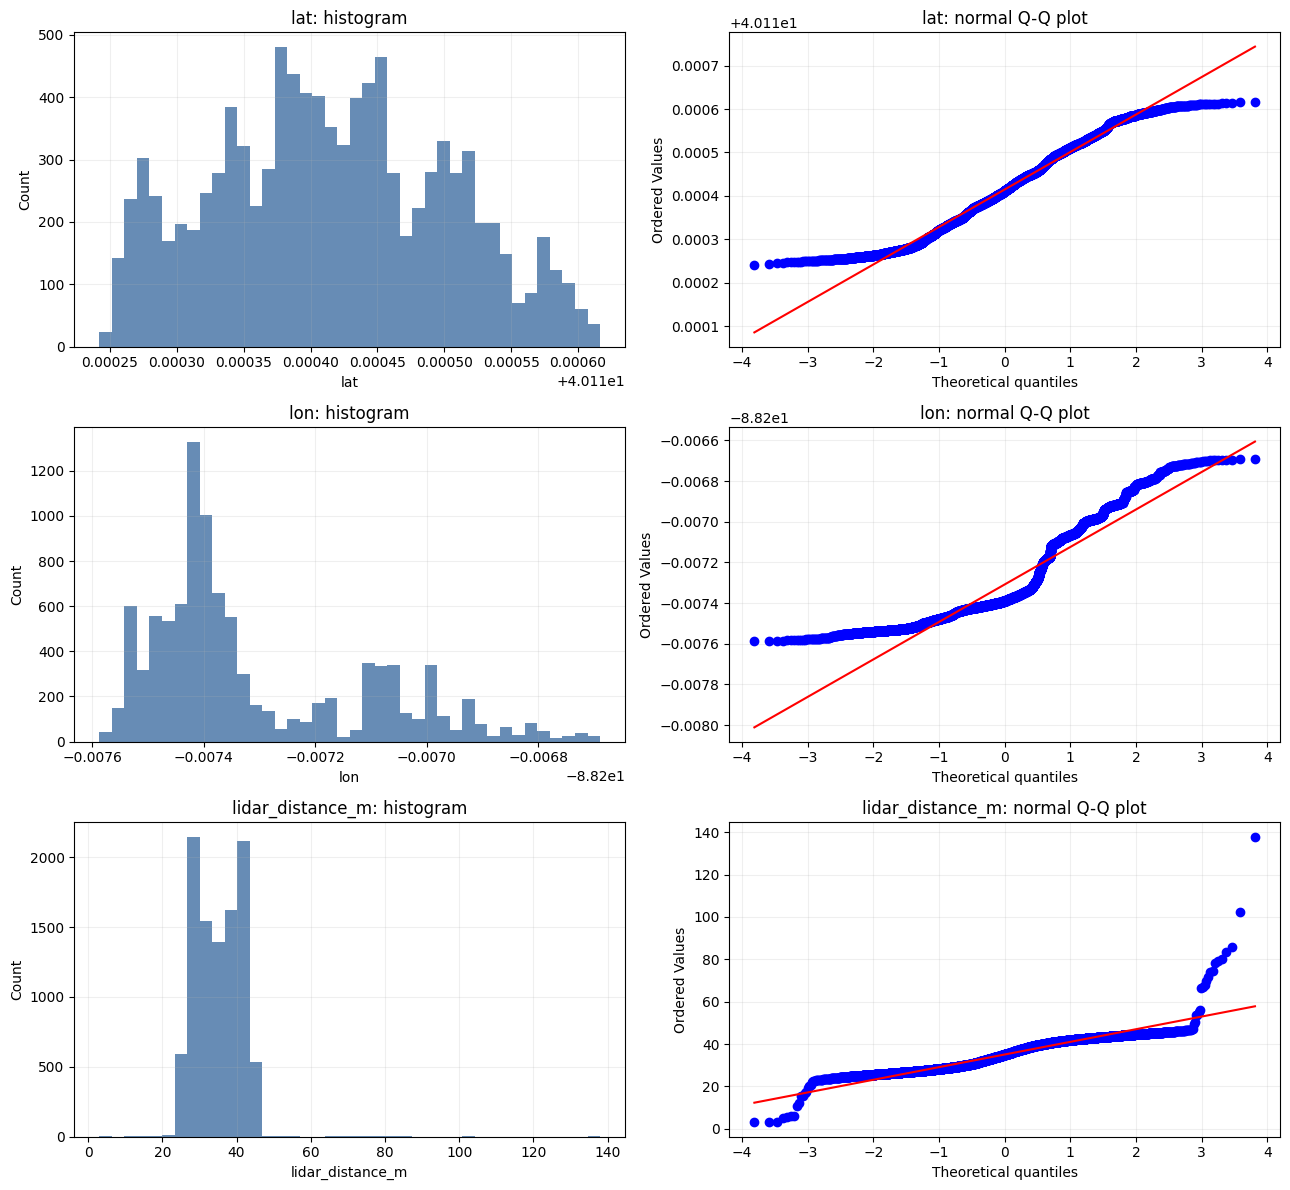

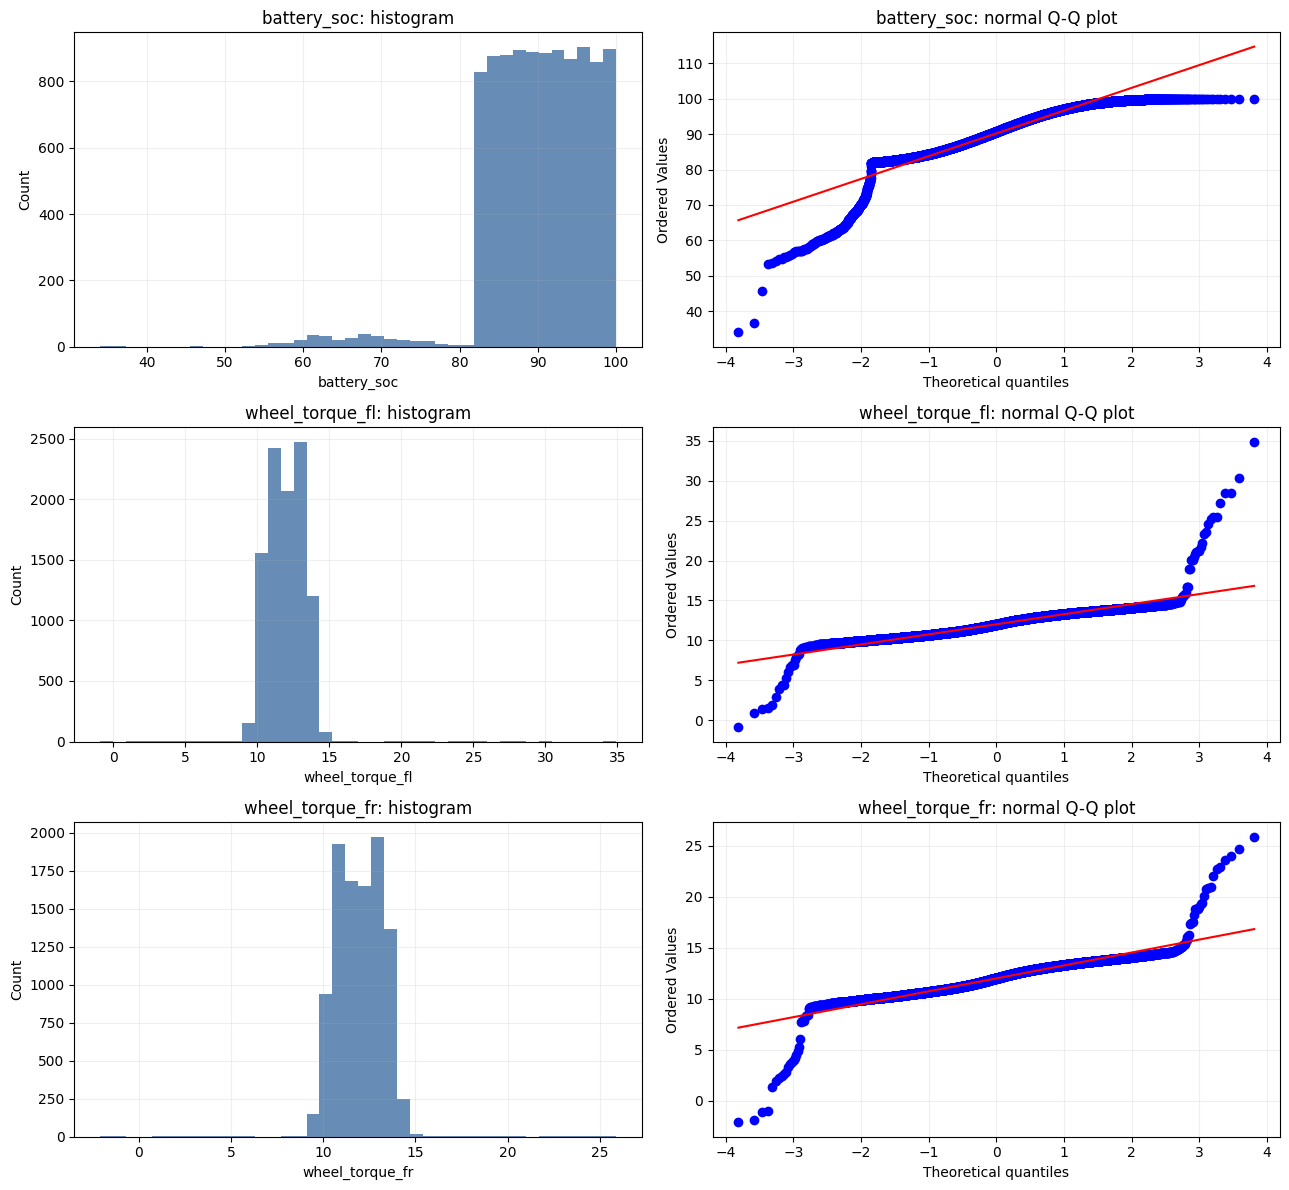

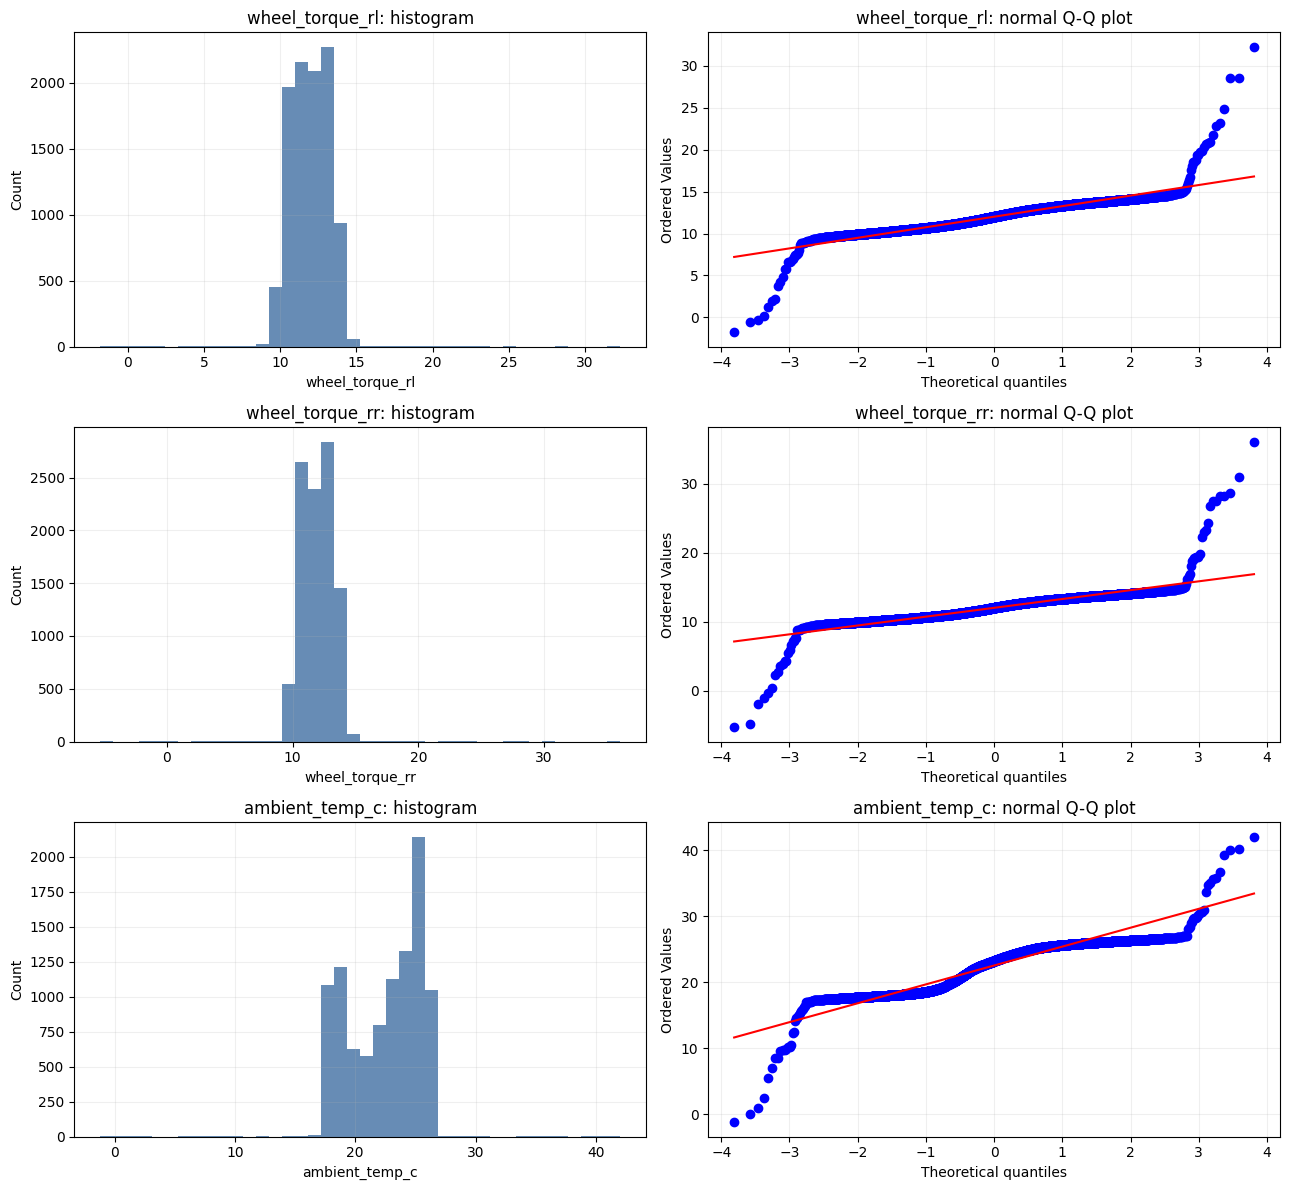

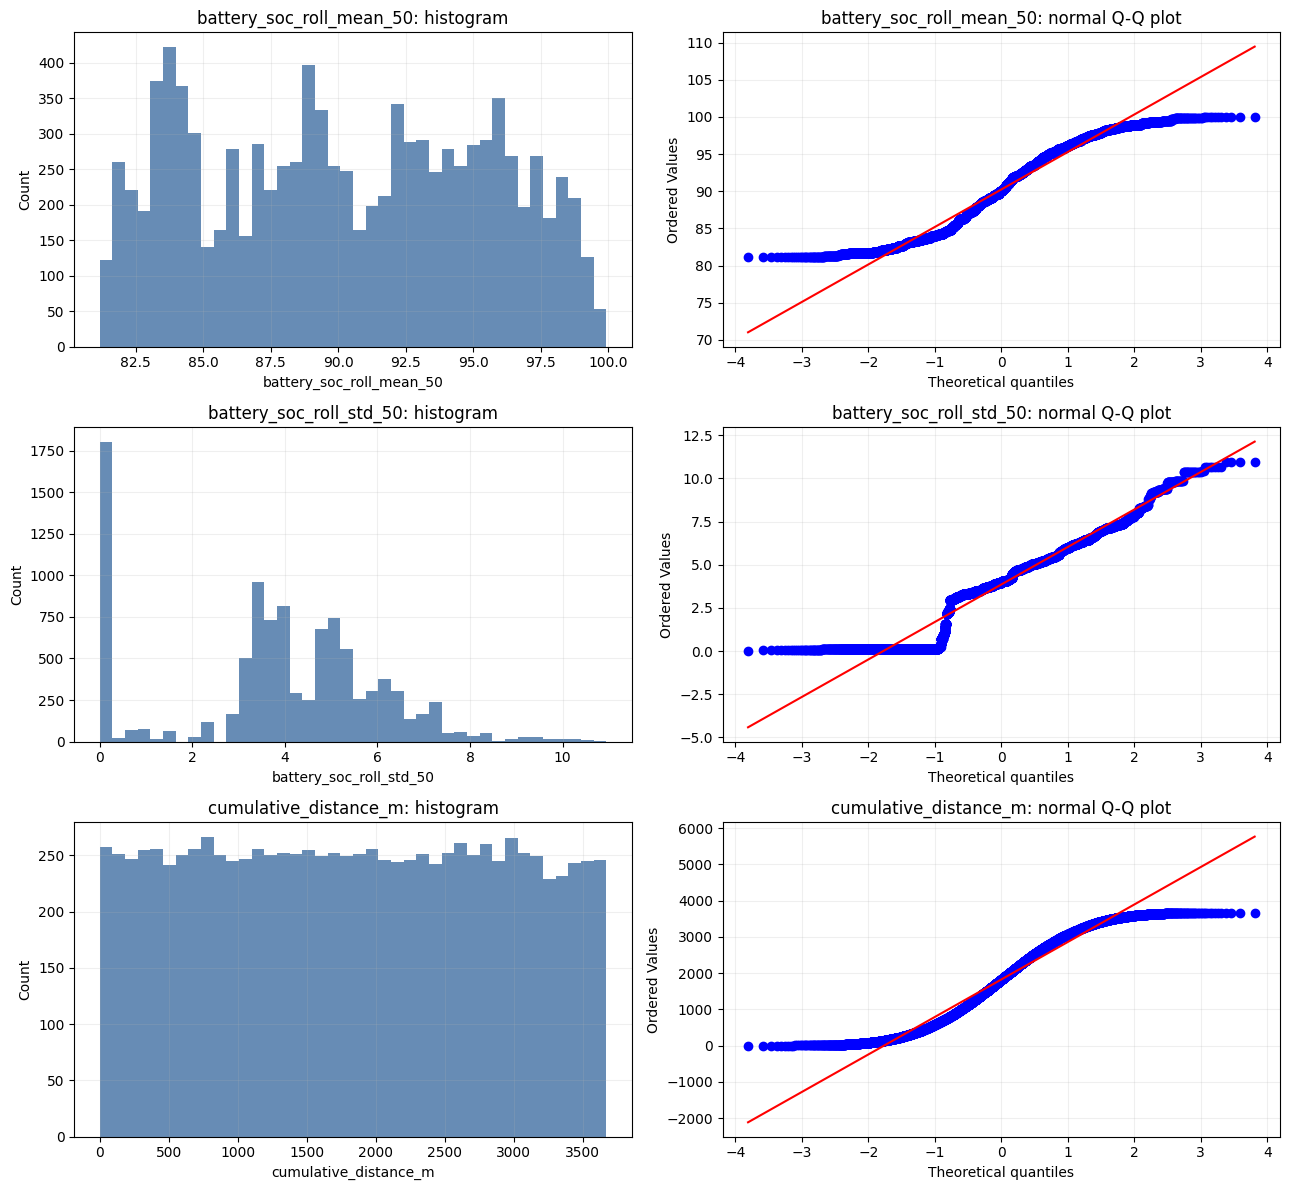

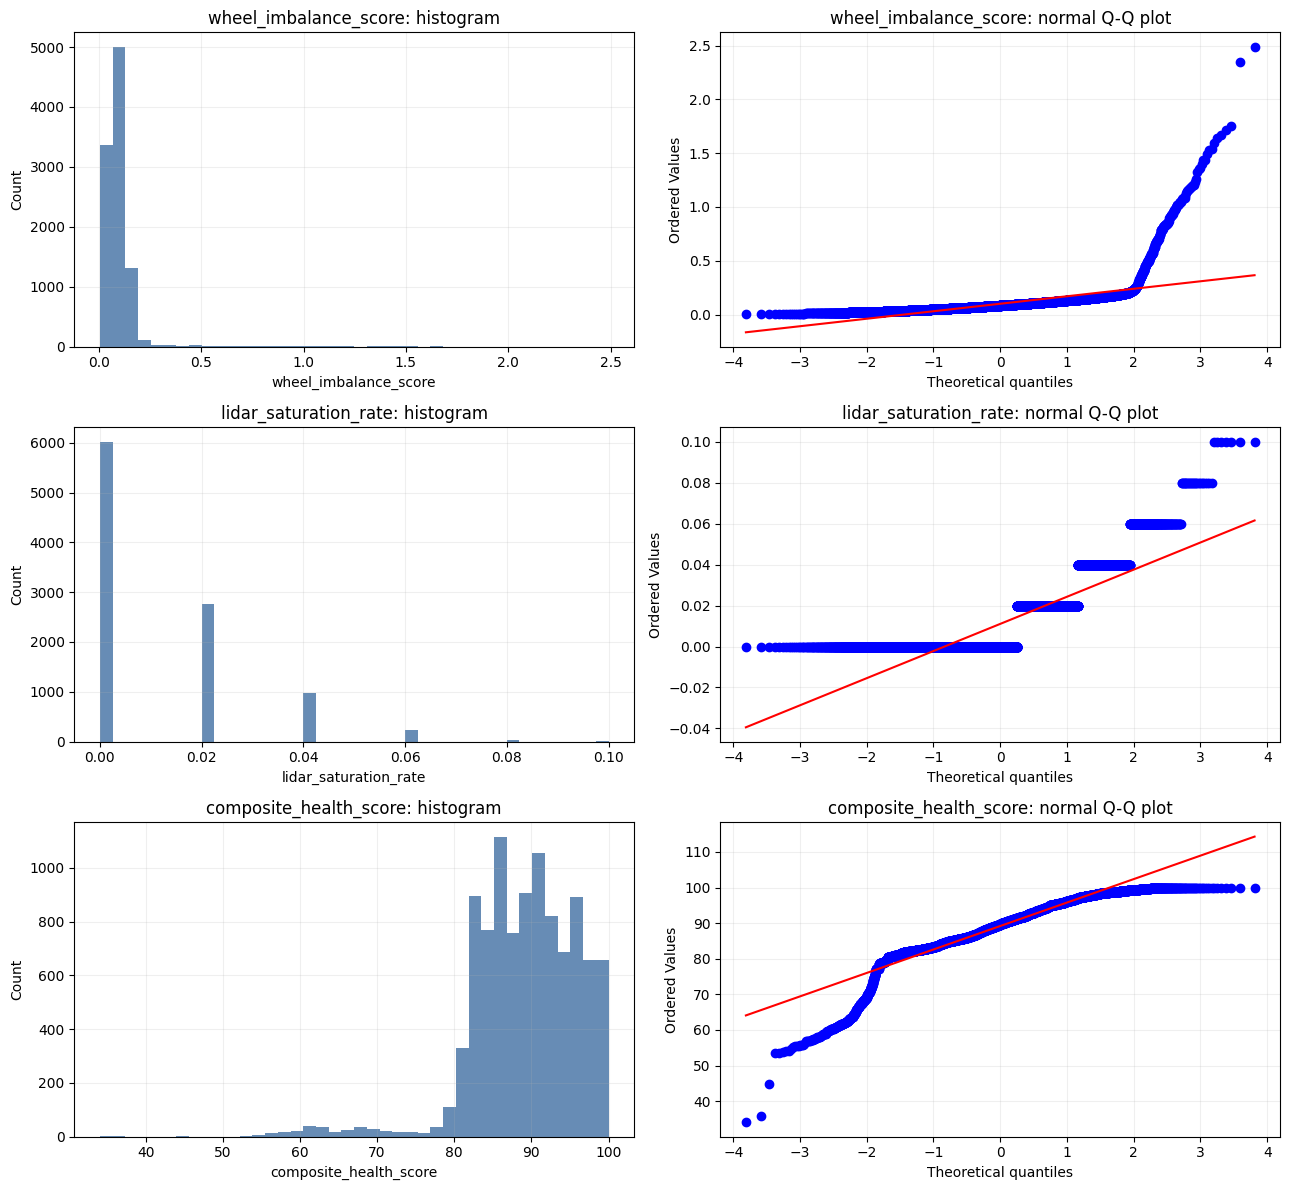

Interpretation guardrail: normality-test significance alone does not establish practically important non-normality; sample size and the histogram/Q-Q effect pattern must also be considered.


In [3]:
FIELDS_PER_FIGURE = 3
for start in range(0, len(CONTINUOUS_FIELDS), FIELDS_PER_FIGURE):
    batch = CONTINUOUS_FIELDS[start : start + FIELDS_PER_FIGURE]
    fig, axes = plt.subplots(len(batch), 2, figsize=(13, 4 * len(batch)))
    axes = np.atleast_2d(axes)
    for row, field in enumerate(batch):
        values = df[field].to_numpy(dtype=float)
        axes[row, 0].hist(values, bins=40, color="#4C78A8", alpha=0.85)
        axes[row, 0].set(
            title=f"{field}: histogram",
            xlabel=field,
            ylabel="Count",
        )
        axes[row, 0].grid(alpha=0.2)
        stats.probplot(values, dist="norm", plot=axes[row, 1])
        axes[row, 1].set_title(f"{field}: normal Q-Q plot")
        axes[row, 1].grid(alpha=0.2)
    fig.tight_layout()
    plt.show()

print(
    "Interpretation guardrail: normality-test significance alone does not "
    "establish practically important non-normality; sample size and the "
    "histogram/Q-Q effect pattern must also be considered."
)

## 2. Pearson and Spearman correlation analysis

Every unordered pair of continuous fields is tested with both Pearson and Spearman methods. Benjamini–Hochberg false-discovery-rate correction is applied separately within each method’s 105-pair family. The full machine-readable table retains numeric raw and adjusted p-values; notebook prose uses threshold formatting for extremely small values.

In [4]:
correlation_results = calculate_pairwise_correlations(
    df,
    columns=CONTINUOUS_FIELDS,
    methods=("pearson", "spearman"),
)
correlation_path = OUTPUT_DIR / "correlation_results.csv"
correlation_results.to_csv(correlation_path, index=False, float_format="%.17g")

expected_pairs = len(CONTINUOUS_FIELDS) * (len(CONTINUOUS_FIELDS) - 1) // 2
assert len(correlation_results) == expected_pairs * 2
assert correlation_results.groupby("method").size().eq(expected_pairs).all()
assert correlation_results["n"].eq(10_000).all()
assert correlation_results["raw_p_value"].between(0.0, 1.0).all()
assert correlation_results["bh_adjusted_p_value"].between(0.0, 1.0).all()

correlation_report = correlation_results.assign(
    raw_p_value_report=correlation_results["raw_p_value"].map(format_p_value),
    bh_adjusted_p_value_report=correlation_results[
        "bh_adjusted_p_value"
    ].map(format_p_value),
)[
    [
        "variable_x",
        "variable_y",
        "method",
        "coefficient",
        "raw_p_value_report",
        "bh_adjusted_p_value_report",
        "n",
    ]
]

print(f"Saved all {len(correlation_results):,} tests: {correlation_path.resolve()}")
display(correlation_report.head(12).round(6))

Saved all 210 tests: C:\ingen\outputs\w05_eda\correlation_results.csv


,variable_x,variable_y,method,coefficient,raw_p_value_report,bh_adjusted_p_value_report,n
0,lat,lon,pearson,-0.019233,p = 0.054,p = 0.063,10000
1,lat,lidar_distance_m,pearson,0.083790,p < 0.001,p < 0.001,10000
2,lat,battery_soc,pearson,0.170927,p < 0.001,p < 0.001,10000
3,lat,wheel_torque_fl,pearson,0.220828,p < 0.001,p < 0.001,10000
4,lat,wheel_torque_fr,pearson,0.217351,p < 0.001,p < 0.001,10000
5,lat,wheel_torque_rl,pearson,0.243373,p < 0.001,p < 0.001,10000
6,lat,wheel_torque_rr,pearson,0.222846,p < 0.001,p < 0.001,10000
7,lat,ambient_temp_c,pearson,-0.155342,p < 0.001,p < 0.001,10000
8,lat,battery_soc_roll_mean_50,pearson,0.228100,p < 0.001,p < 0.001,10000
9,lat,battery_soc_roll_std_50,pearson,0.035054,p < 0.001,p < 0.001,10000


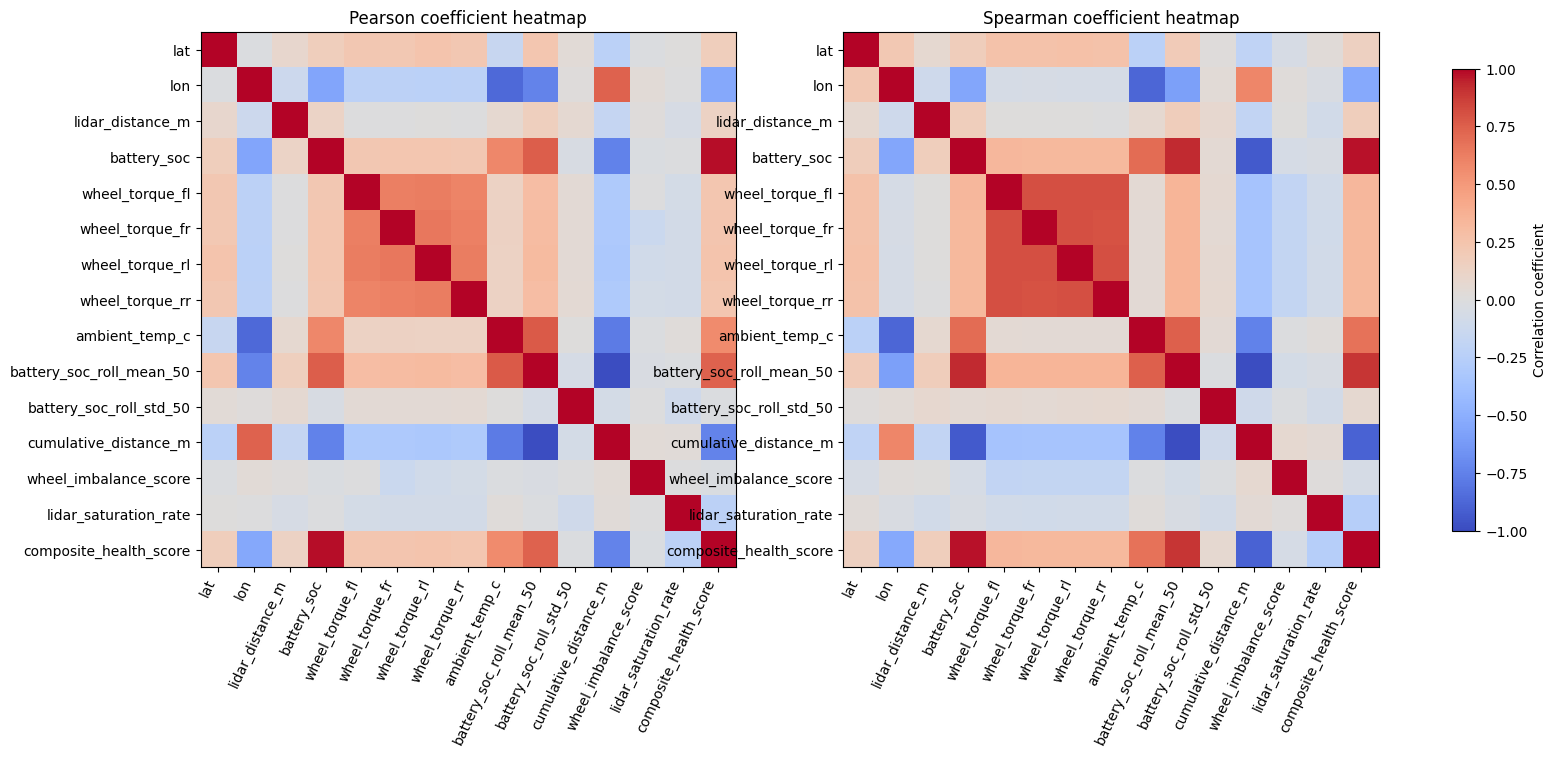

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(19, 8))
for ax, method, title in (
    (axes[0], "pearson", "Pearson coefficient heatmap"),
    (axes[1], "spearman", "Spearman coefficient heatmap"),
):
    matrix = df.loc[:, CONTINUOUS_FIELDS].corr(method=method)
    image = ax.imshow(matrix, cmap="coolwarm", vmin=-1.0, vmax=1.0)
    ax.set_xticks(
        range(len(CONTINUOUS_FIELDS)),
        labels=CONTINUOUS_FIELDS,
        rotation=65,
        ha="right",
    )
    ax.set_yticks(range(len(CONTINUOUS_FIELDS)), labels=CONTINUOUS_FIELDS)
    ax.set_title(title)
fig.colorbar(image, ax=axes, shrink=0.75, label="Correlation coefficient")
plt.show()

In [6]:
print("Largest absolute coefficients (descriptive associations only):")
for method in ("pearson", "spearman"):
    strongest = (
        correlation_results.loc[correlation_results["method"].eq(method)]
        .assign(absolute_coefficient=lambda table: table["coefficient"].abs())
        .sort_values(
            ["absolute_coefficient", "variable_x", "variable_y"],
            ascending=[False, True, True],
            kind="mergesort",
        )
        .head(3)
    )
    for row in strongest.itertuples(index=False):
        adjusted_report = format_p_value(row.bh_adjusted_p_value)
        print(
            f"- {row.variable_x} vs {row.variable_y}: method={method}, "
            f"coefficient={row.coefficient:.6f}, BH-adjusted "
            f"{adjusted_report}, n={row.n:,}. This association does not "
            "establish causation."
        )

Largest absolute coefficients (descriptive associations only):
- battery_soc_roll_mean_50 vs cumulative_distance_m: method=pearson, coefficient=-0.991581, BH-adjusted p < 0.001, n=10,000. This association does not establish causation.
- battery_soc vs composite_health_score: method=pearson, coefficient=0.978270, BH-adjusted p < 0.001, n=10,000. This association does not establish causation.
- lon vs ambient_temp_c: method=pearson, coefficient=-0.861979, BH-adjusted p < 0.001, n=10,000. This association does not establish causation.
- battery_soc_roll_mean_50 vs cumulative_distance_m: method=spearman, coefficient=-0.991624, BH-adjusted p < 0.001, n=10,000. This association does not establish causation.
- battery_soc vs composite_health_score: method=spearman, coefficient=0.968971, BH-adjusted p < 0.001, n=10,000. This association does not establish causation.
- battery_soc vs cumulative_distance_m: method=spearman, coefficient=-0.930027, BH-adjusted p < 0.001, n=10,000. This association

## 3. Global outlier rules versus sliding-window reference detector

IQR fences and absolute population z-score `> 3` are applied to the seven raw continuous sensor fields that have corresponding spike flags. Each global rule is compared with the existing sliding-window flag through detector counts, intersection, union, and Jaccard similarity. The sliding-window flag is a reference detector—not ground truth—so disagreement does not by itself identify an error.

In [7]:
outlier_results = compare_outlier_detectors(
    df,
    reference_flags=OUTLIER_REFERENCE_FLAGS,
)
outlier_path = OUTPUT_DIR / "outlier_comparison.csv"
outlier_results.to_csv(outlier_path, index=False, float_format="%.17g")

assert len(outlier_results) == len(OUTLIER_REFERENCE_FLAGS) * 2
assert outlier_results["n"].eq(10_000).all()
assert outlier_results["jaccard_similarity"].between(0.0, 1.0).all()
assert (
    outlier_results["intersection_count"]
    <= outlier_results["union_count"]
).all()

print(f"Saved complete detector comparison: {outlier_path.resolve()}")
print("Reference status: sliding-window detector, not ground truth.")
display(outlier_results.round(6))

Saved complete detector comparison: C:\ingen\outputs\w05_eda\outlier_comparison.csv
Reference status: sliding-window detector, not ground truth.


,variable,reference_flag,method,detector_flagged_count,reference_flagged_count,intersection_count,union_count,jaccard_similarity,n
0,lidar_distance_m,lidar_distance_m_spike,IQR (1.5 × IQR),23,93,22,94,0.234043,10000
1,lidar_distance_m,lidar_distance_m_spike,|z-score| > 3,28,93,27,94,0.287234,10000
2,battery_soc,battery_soc_spike,IQR (1.5 × IQR),261,321,256,326,0.785276,10000
3,battery_soc,battery_soc_spike,|z-score| > 3,219,321,215,325,0.661538,10000
4,wheel_torque_fl,wheel_torque_fl_spike,IQR (1.5 × IQR),41,98,40,99,0.404040,10000
5,wheel_torque_fl,wheel_torque_fl_spike,|z-score| > 3,41,98,40,99,0.404040,10000
6,wheel_torque_fr,wheel_torque_fr_spike,IQR (1.5 × IQR),47,118,47,118,0.398305,10000
7,wheel_torque_fr,wheel_torque_fr_spike,|z-score| > 3,47,118,47,118,0.398305,10000
8,wheel_torque_rl,wheel_torque_rl_spike,IQR (1.5 × IQR),44,101,44,101,0.435644,10000
9,wheel_torque_rl,wheel_torque_rl_spike,|z-score| > 3,44,101,44,101,0.435644,10000


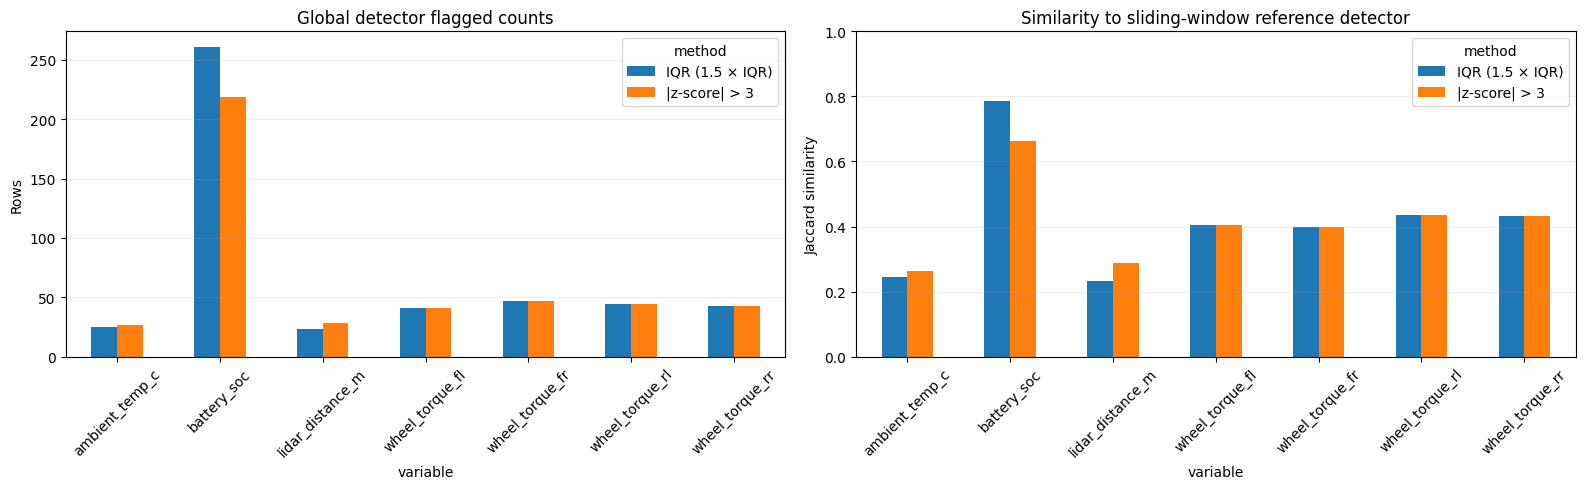

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
count_pivot = outlier_results.pivot(
    index="variable",
    columns="method",
    values="detector_flagged_count",
)
count_pivot.plot.bar(ax=axes[0])
axes[0].set(title="Global detector flagged counts", ylabel="Rows")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.2)

jaccard_pivot = outlier_results.pivot(
    index="variable",
    columns="method",
    values="jaccard_similarity",
)
jaccard_pivot.plot.bar(ax=axes[1])
axes[1].set(
    title="Similarity to sliding-window reference detector",
    ylabel="Jaccard similarity",
    ylim=(0.0, 1.0),
)
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()

## Interpretation limits

- With `n = 10,000`, small deviations can generate very small p-values; practical importance requires examining effect size and plots.
- Pearson and Spearman coefficients describe association, not causation.
- Multiple-testing control limits the expected false-discovery proportion within each correlation-method family; it does not validate a causal model.
- IQR, z-score, and sliding-window rules answer different detector questions. The sliding-window flags are reference outputs, not ground-truth labels.

## 4. Anomaly-type classifier evaluation

`anomaly_type` is a **rule-derived proxy label**, not independent human-labelled ground truth. The experiment asks: given that a row is already known to be one unambiguous anomaly category, which of `gps`, `lidar`, `battery`, `wheel_torque`, or `ambient_temp` is it? The 8,816 `normal` rows and 47 `overlap` rows are excluded.

The held-out test set is created once with a fixed, stratified split. Five-fold cross-validation is performed only on the training split. Candidate selection uses training CV macro-F1; held-out test metrics do not tune or select the model.

In [9]:
from W05_Predictive_Models import (
    load_classifier_dataset,
    run_classifier_experiment,
    save_classifier_outputs,
)
from ingen_pydev.modeling.anomaly import (
    CLASSIFIER_FEATURES,
    CLASSIFIER_LABELS,
    LABEL_SOURCE_FLAGS,
    LEAKAGE_EXCLUDED_DERIVED_FEATURES,
)

CLASSIFIER_OUTPUT_DIR = Path("outputs/w05_classifier")
X_classifier, y_classifier = load_classifier_dataset()
classifier_result = run_classifier_experiment()
classifier_output_paths = save_classifier_outputs(
    classifier_result,
    CLASSIFIER_OUTPUT_DIR,
)

assert X_classifier.shape == (1_137, len(CLASSIFIER_FEATURES))
assert set(y_classifier.unique()) == set(CLASSIFIER_LABELS)
assert "normal" not in y_classifier.values
assert "overlap" not in y_classifier.values
assert set(X_classifier.columns).isdisjoint(LABEL_SOURCE_FLAGS)
assert set(X_classifier.columns).isdisjoint(
    LEAKAGE_EXCLUDED_DERIVED_FEATURES
)
assert classifier_result.train_n + classifier_result.test_n == 1_137
assert classifier_result.train_n == 909
assert classifier_result.test_n == 228

print("Classifier target class counts:")
print(y_classifier.value_counts().reindex(CLASSIFIER_LABELS).to_string())
print(
    f"\nStratified held-out split: train n = {classifier_result.train_n:,}; "
    f"test n = {classifier_result.test_n:,}"
)
print("Cross-validation scope: training split only; held-out test not used.")

Classifier target class counts:
anomaly_type
gps             189
lidar           182
battery         297
wheel_torque    374
ambient_temp     95

Stratified held-out split: train n = 909; test n = 228
Cross-validation scope: training split only; held-out test not used.


In [10]:
cv_report = classifier_result.cv_results[
    [
        "model",
        "cv_mean_macro_f1",
        "cv_std_macro_f1",
        "cv_folds",
        "fold_1_macro_f1",
        "fold_2_macro_f1",
        "fold_3_macro_f1",
        "fold_4_macro_f1",
        "fold_5_macro_f1",
    ]
]
display(cv_report.round(6))
print(
    f"Selected model: {classifier_result.selected_model_name}. Selection "
    "used the highest training-set CV mean macro-F1 only; no held-out "
    "test metric was consulted."
)

,model,cv_mean_macro_f1,cv_std_macro_f1,cv_folds,fold_1_macro_f1,fold_2_macro_f1,fold_3_macro_f1,fold_4_macro_f1,fold_5_macro_f1
0,Dummy most-frequent,0.099006,0.000336,5,0.099174,0.099174,0.099174,0.099174,0.098333
1,Logistic regression,0.562860,0.030144,5,0.604504,0.575946,0.564949,0.511876,0.557023
2,Random forest,0.696283,0.029439,5,0.737505,0.706912,0.692497,0.646255,0.698248


Selected model: Random forest. Selection used the highest training-set CV mean macro-F1 only; no held-out test metric was consulted.


In [11]:
selected = classifier_result.selected_evaluation
baseline = classifier_result.baseline_evaluation
report_rows = [*CLASSIFIER_LABELS, "macro avg", "weighted avg"]

print(f"Held-out classification report — {selected.name}")
display(selected.classification_report.loc[report_rows].round(6))
print(
    f"Selected model held-out macro-F1 = {selected.macro_f1:.6f}; "
    f"weighted-F1 = {selected.weighted_f1:.6f}."
)

print(f"Most-frequent baseline report — {baseline.name}")
display(baseline.classification_report.loc[report_rows].round(6))
print(
    f"Most-frequent baseline held-out macro-F1 = {baseline.macro_f1:.6f}; "
    f"weighted-F1 = {baseline.weighted_f1:.6f}."
)
print("Held-out comparison:")
display(classifier_result.holdout_comparison.round(6))

Held-out classification report — Random forest


,precision,recall,f1-score,support
label,,,,
gps,0.500000,0.578947,0.536585,38.0
lidar,0.473684,0.500000,0.486486,36.0
battery,1.000000,0.983333,0.991597,60.0
wheel_torque,0.904110,0.880000,0.891892,75.0
ambient_temp,1.000000,0.736842,0.848485,19.0
macro avg,0.775559,0.735825,0.751009,228.0
weighted avg,0.802021,0.785088,0.791284,228.0


Selected model held-out macro-F1 = 0.751009; weighted-F1 = 0.791284.
Most-frequent baseline report — Dummy most-frequent


,precision,recall,f1-score,support
label,,,,
gps,0.000000,0.000000,0.000000,38.0
lidar,0.000000,0.000000,0.000000,36.0
battery,0.000000,0.000000,0.000000,60.0
wheel_torque,0.328947,1.000000,0.495050,75.0
ambient_temp,0.000000,0.000000,0.000000,19.0
macro avg,0.065789,0.200000,0.099010,228.0
weighted avg,0.108206,0.328947,0.162845,228.0


Most-frequent baseline held-out macro-F1 = 0.099010; weighted-F1 = 0.162845.
Held-out comparison:


,model,accuracy,macro_f1,weighted_f1,selection_role
0,Random forest,0.785088,0.751009,0.791284,Selected by training CV
1,Dummy most-frequent,0.328947,0.099010,0.162845,Predefined baseline


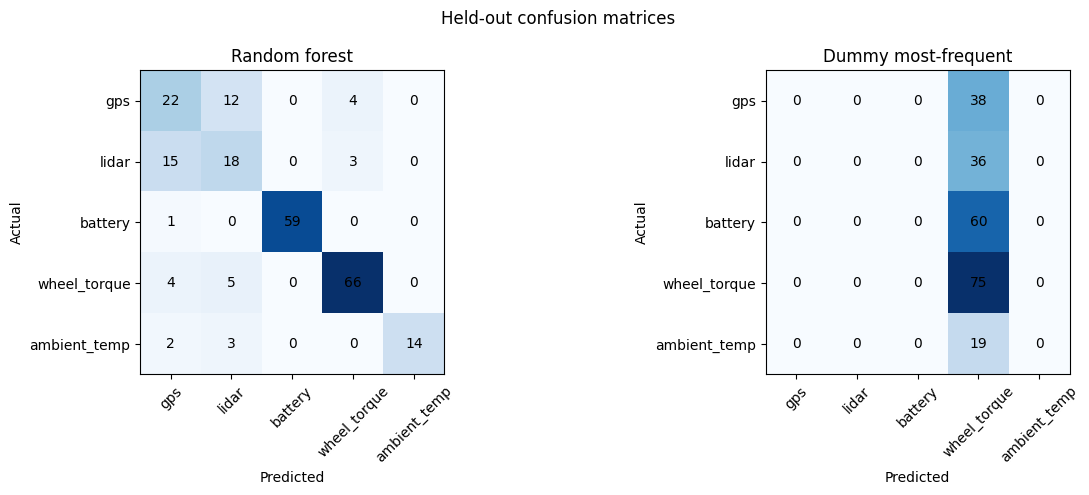

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, evaluation in (
    (axes[0], selected),
    (axes[1], baseline),
):
    matrix = evaluation.confusion_matrix
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_xticks(range(len(CLASSIFIER_LABELS)), labels=CLASSIFIER_LABELS)
    ax.set_yticks(range(len(CLASSIFIER_LABELS)), labels=CLASSIFIER_LABELS)
    ax.tick_params(axis="x", rotation=45)
    ax.set(
        title=evaluation.name,
        xlabel="Predicted",
        ylabel="Actual",
    )
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            ax.text(
                column,
                row,
                int(matrix.iloc[row, column]),
                ha="center",
                va="center",
            )
fig.suptitle("Held-out confusion matrices")
fig.tight_layout()
plt.show()

In [13]:
saved_classifier_outputs = pd.DataFrame(
    {
        "artifact": classifier_output_paths.keys(),
        "path": [str(path.resolve()) for path in classifier_output_paths.values()],
    }
)
print("Saved reproducible classifier outputs:")
display(saved_classifier_outputs)

Saved reproducible classifier outputs:


,artifact,path
0,cv_results,C:\ingen\outputs\w05_classifier\cv_results.csv
1,selected_classification_report,C:\ingen\outputs\w05_classifier\selected_class...
2,selected_confusion_matrix,C:\ingen\outputs\w05_classifier\selected_confu...
3,baseline_classification_report,C:\ingen\outputs\w05_classifier\baseline_class...
4,baseline_confusion_matrix,C:\ingen\outputs\w05_classifier\baseline_confu...
5,holdout_comparison,C:\ingen\outputs\w05_classifier\holdout_compar...


### Classifier interpretation limit

These results measure agreement with deterministic pipeline rules on synthetic telemetry. Because `anomaly_type` is derived from those rules rather than independently assigned by human reviewers, held-out performance must not be presented as validation against independent real-world ground truth.